In [1]:
# Cell 1: Install required libraries (No bitsandbytes required for unquantized)
!pip install transformers matplotlib seaborn torch accelerate

In [2]:
# Cell 2
! pip install git+https://github.com/huggingface/transformers.git --upgrade

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-o7fa_fn7
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-o7fa_fn7
  Resolved https://github.com/huggingface/transformers.git to commit a29df2d916e3b820aecd19d3b5a877abc523ba3c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.6.0.dev0-py3-none-any.whl size=11447989 sha256=ec3bc21404a56fc3f231a97c1e244dd05a7af0f5c9888b28c74c057181cfbf77
  Stored in directory: /tmp/pip-ephem-wheel-cache-iea_oeqk/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [3]:
# Cell 3: Load model
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen3.5-4B"
print(f"Loading {model_name}...")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

# Load model in standard precision (no 4-bit quantization)
# torch_dtype=torch.bfloat16 or float16 is recommended to avoid OOM errors
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    output_attentions=True,
    trust_remote_code=True,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

Loading Qwen/Qwen3.5-4B...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

In [4]:
# Cell 4
# Define input query
query = "What is it like to be a bat?"
inputs = tokenizer(query, return_tensors='pt').to(model.device)

# Process query and extract attention weights
print("Processing input and extracting attention weights...")
with torch.no_grad():
    outputs = model(**inputs)
    attentions = outputs.attentions  # List of tensors (one per layer)

# Get token labels for visualization
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

Processing input and extracting attention weights...


Error: 'attentions' is None. Re-running inference with explicit output_attentions=True...
Generating detailed visualization...


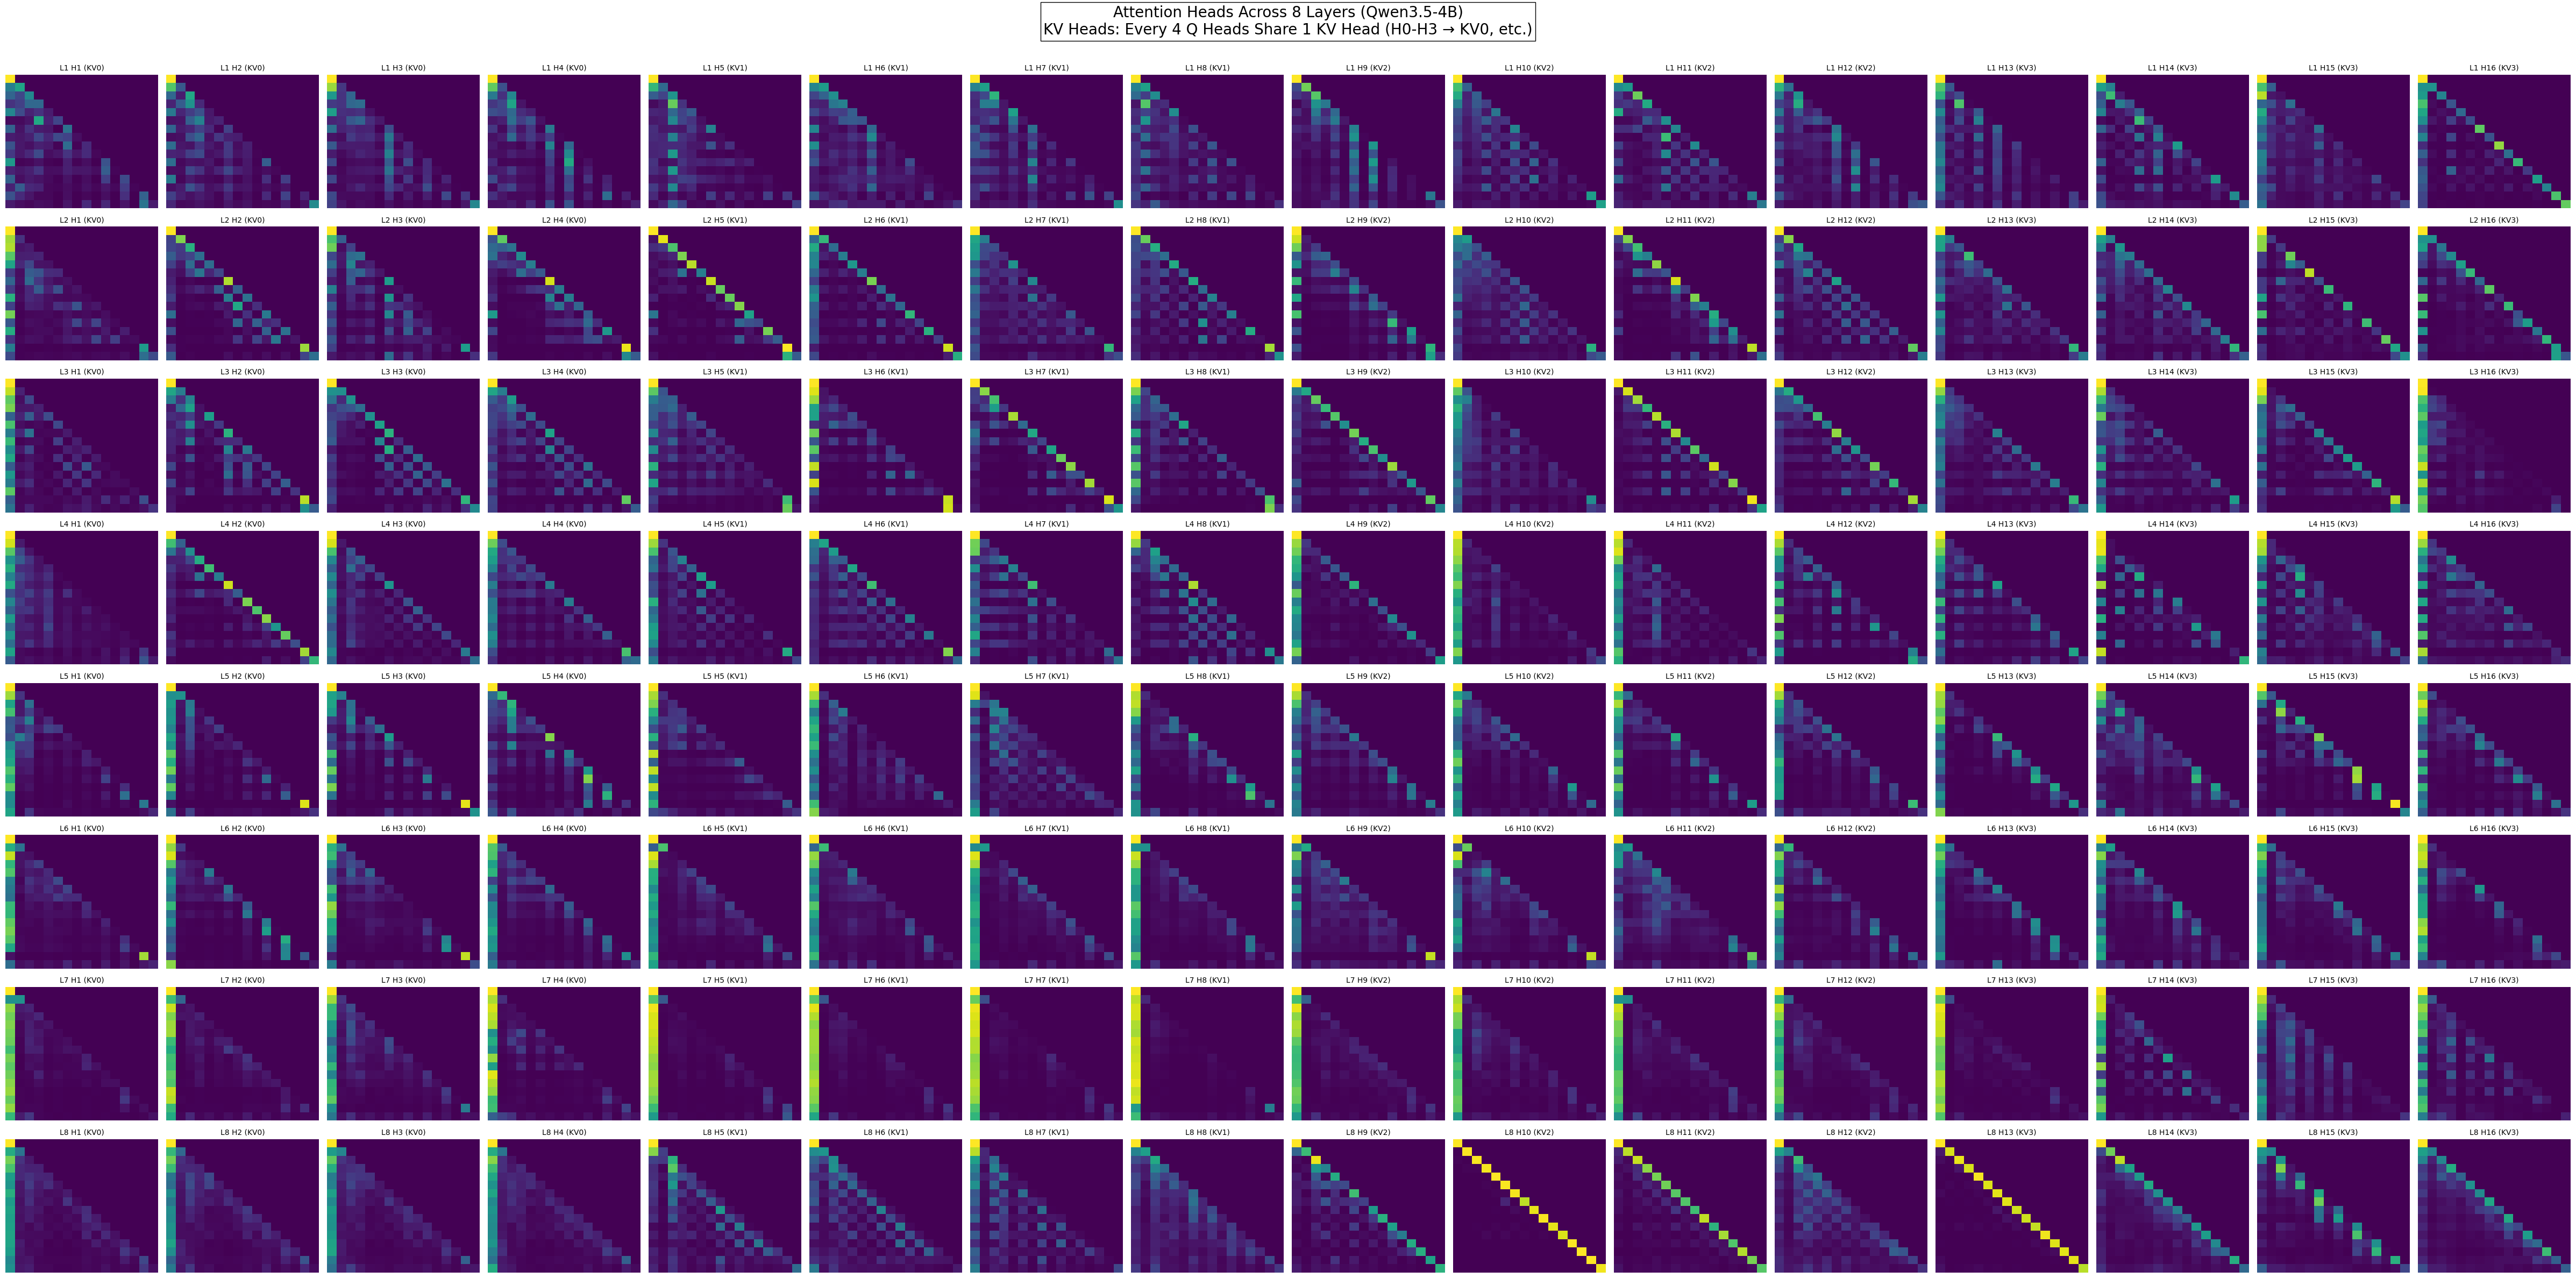

Visualization saved as 'qwen3.5_attention_detailed.png'
File successfully generated.


In [9]:
# Cell 5: Visualization of Attention Heads
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import os

def visualize_all_heads_detailed(tokens, attentions):
    if attentions is None:
        print("Error: 'attentions' is None. Re-running inference with explicit output_attentions=True...")
        # Ensure we use the correct inputs from the previous cell
        inputs = tokenizer(" ".join(tokens).replace("Ġ", " "), return_tensors='pt').to(model.device)
        with torch.no_grad():
            outputs = model(**inputs, output_attentions=True)
            attentions = outputs.attentions

    if attentions is None:
        print("Critical Error: Could not extract attentions. Check if the model supports output_attentions.")
        return

    print("Generating detailed visualization...")

    # Dynamically extract layers and heads
    num_layers = len(attentions)
    num_heads = attentions[0].shape[1]

    # Qwen3.5-4B GQA: 16 Q heads / 4 KV heads = 4 Q heads per KV head
    q_per_kv = 4

    # Create a grid
    fig, axes = plt.subplots(num_layers, num_heads, figsize=(num_heads * 3, num_layers * 3), facecolor='none')

    title_text = (
        f'Attention Heads Across {num_layers} Layers (Qwen3.5-4B)\n'
        f'KV Heads: Every {q_per_kv} Q Heads Share 1 KV Head (H0-H3 → KV0, etc.)'
    )

    fig.suptitle(title_text, fontsize=20, y=0.998, bbox=dict(facecolor='none'))

    for layer_idx, attention_layer in enumerate(attentions):
        for head_idx in range(num_heads):
            # Handle 1D axes array if only one layer exists
            if num_layers > 1:
                ax = axes[layer_idx, head_idx]
            else:
                ax = axes[head_idx]

            # Cast to float32 for plotting
            attn = attention_layer[0, head_idx].detach().cpu().float().numpy()

            # Determine shared KV head index
            kv_idx = head_idx // q_per_kv

            # Plot heatmap
            sns.heatmap(
                attn,
                xticklabels=tokens,
                yticklabels=tokens,
                cmap='viridis',
                ax=ax,
                cbar=False,
                annot=False
            )

            ax.set_title(f'L{layer_idx+1} H{head_idx+1} (KV{kv_idx})', fontsize=10)
            ax.tick_params(axis='both', which='both', length=0)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_facecolor('none')

    plt.tight_layout(rect=[0, 0.01, 1, 0.99])
    file_name = 'qwen3.5_attention_detailed.png'
    plt.savefig(file_name, format='png', dpi=150, transparent=True, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Visualization saved as '{file_name}'")

# Run visualization
visualize_all_heads_detailed(tokens, attentions)

# Verify file was created
if os.path.exists('qwen3.5_attention_detailed.png'):
    print("File successfully generated.")
else:
    print("File generation failed.")